In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

# 1. Exploratory Data analysis

In [3]:
df2=pd.read_excel("online_retail_II.xlsx")

In [4]:
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df2.shape

(525461, 8)

In [6]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [7]:
df2.count()

Invoice        525461
StockCode      525461
Description    522533
Quantity       525461
InvoiceDate    525461
Price          525461
Customer ID    417534
Country        525461
dtype: int64

In [8]:
df2.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [9]:
df2['IsCancellation'] = df2['Invoice'].astype(str).str.startswith('C')

In [10]:
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False


In [17]:
df2['IsCancellation'].value_counts()

IsCancellation
False    515255
True      10206
Name: count, dtype: int64

In [18]:
print(df2['IsCancellation'].sum(), "cancellation rows")
print((df2['Price'] <= 0).sum(), "rows with Price <= 0")
print((df2['Quantity'] <= 0).sum(), "rows with Quantity <= 0")

10206 cancellation rows
3690 rows with Price <= 0
12326 rows with Quantity <= 0


In [ ]:
# rows with negative/zero quantity but NOT flagged as cancellation
mismatch = df2[(df2['Quantity'] <= 0) & (~df2['IsCancellation'])]
print(mismatch[['Invoice','StockCode','Description','Quantity','Price']].head(15))

     Invoice StockCode      Description  Quantity  Price
263   489464     21733     85123a mixed       -96    0.0
283   489463     71477            short      -240    0.0
284   489467    85123A      21733 mixed      -192    0.0
470   489521     21646              NaN       -50    0.0
3114  489655     20683              NaN       -44    0.0
3162  489660     35956             lost     -1043    0.0
3168  489663    35605A          damages      -117    0.0
4296  489806     18010              NaN      -770    0.0
4538  489820     21133  invcd as 84879?      -720    0.0
4566  489821    85049G              NaN      -240    0.0
6556  489899   79323GR     sold as gold      -954    0.0
6576  489901     21098              NaN      -200    0.0
6911  490007     84347            21494      -720    0.0
7205  490016     21982              NaN     -1012    0.0
7559  490055     20620              NaN       -25    0.0


In [20]:
# what StockCodes show up when price <= 0
print(df2[df2['Price'] <= 0]['StockCode'].value_counts().head(15))

StockCode
46000M    12
84016     11
22423     11
79321     10
84990     10
22469     10
22950     10
22197      9
22139      9
21116      8
84795D     8
22501      8
22734      8
46000S     7
21768      7
Name: count, dtype: int64


In [21]:
# same for the mismatch group
print(mismatch['StockCode'].value_counts().head(15))

StockCode
22423     9
46000M    5
84016     5
20852     5
71477     4
21768     4
21493     3
21489     3
21490     3
79030A    3
10138     3
72739B    3
37503     3
72739C    3
17129D    3
Name: count, dtype: int64


In [42]:
# finalize clean data
df_clean = df2[df2['Price'] > 0].copy()
df_clean['IsCancellation'] = df_clean['Invoice'].astype(str).str.startswith('C')
sales_only = df_clean[~df_clean['IsCancellation']].copy()

# build daily demand series per product
sales_only['Date'] = sales_only['InvoiceDate'].dt.date
sales_only['Revenue'] = sales_only['Quantity'] * sales_only['Price']

daily_demand = (
    sales_only.groupby(['StockCode', 'Date'])
    .agg(Quantity=('Quantity', 'sum'), Revenue=('Revenue', 'sum'), Price=('Price', 'mean'))
    .reset_index()
)



In [43]:
#Filter out year and month
daily_demand['Date']=pd.to_datetime(daily_demand['Date'])
daily_demand['year']=daily_demand['Date'].dt.year
daily_demand['month']=daily_demand['Date'].dt.month

print(daily_demand.shape)
daily_demand.head()

(266435, 7)


,StockCode,Date,Quantity,Revenue,Price,year,month
0,10002,2009-12-01,12,10.20,0.85,2009,12
1,10002,2009-12-03,7,5.95,0.85,2009,12
2,10002,2009-12-04,73,62.05,0.85,2009,12
3,10002,2009-12-06,49,41.65,0.85,2009,12
4,10002,2009-12-07,2,1.70,0.85,2009,12


In [28]:
sales_only['Date']=pd.to_datetime(sales_only['Date'])
sales_only["year"]=sales_only["Date"].dt.year
sales_only["month"]=sales_only["Date"].dt.month
sales_only.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,Date,Revenue,year,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,2009-12-01,83.4,2009,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12-01,81.0,2009,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12-01,81.0,2009,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,2009-12-01,100.8,2009,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,2009-12-01,30.0,2009,12


In [30]:
# Season holidays
sales_only['DayOfWeek'] = sales_only['InvoiceDate'].dt.day_name()
sales_only['Invoice_Month'] = sales_only['InvoiceDate'].dt.month
sales_only['Invoice_Year'] = sales_only['InvoiceDate'].dt.year

# Simple holiday flag 
uk_holidays_2010 = ['2010-01-01','2010-12-25','2010-12-26']  # extend for all years in range
sales_only['IsHoliday'] = sales_only['InvoiceDate'].dt.date.astype(str).isin(uk_holidays_2010)

dow_avg = sales_only.groupby('DayOfWeek')['Revenue'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
month_avg = sales_only.groupby('Invoice_Month')['Revenue'].sum()

print(dow_avg)
print(month_avg)

DayOfWeek
Monday       20.322752
Tuesday      21.942459
Wednesday    19.842031
Thursday     21.852885
Friday       22.201976
Saturday     24.507625
Sunday       13.919605
Name: Revenue, dtype: float64
Invoice_Month
1      652708.502
2      553339.736
3      833570.131
4      681528.992
5      659858.860
6      752270.140
7      650712.940
8      697274.910
9      924333.011
10    1165483.910
11    1470272.482
12    1264538.410
Name: Revenue, dtype: float64


In [31]:
sales_only.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,IsCancellation,Date,Revenue,year,month,DayOfWeek,Invoice_Month,Invoice_Year,IsHoliday
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,2009-12-01,83.4,2009,12,Tuesday,12,2009,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12-01,81.0,2009,12,Tuesday,12,2009,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,2009-12-01,81.0,2009,12,Tuesday,12,2009,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,2009-12-01,100.8,2009,12,Tuesday,12,2009,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,2009-12-01,30.0,2009,12,Tuesday,12,2009,False


In [36]:
sales_only["Invoice_Year"].value_counts()

Invoice_Year
2010    465645
2009     43846
Name: count, dtype: int64

In [37]:
sales_only.groupby(["Invoice_Year", "Invoice_Month"]).size()

Invoice_Year  Invoice_Month
2009          12               43846
2010          1                30545
              2                28153
              3                40141
              4                33091
              5                33647
              6                38735
              7                32351
              8                32338
              9                40904
              10               57571
              11               76231
              12               21938
dtype: int64

In [ ]:
#sorting out alphabet StockCode
a=sales_only[sales_only['StockCode'].astype(str).str.isalpha()]
print(a['StockCode'].unique())

['POST' 'DOT' 'M' 'PADS' 'ADJUST' 'm' 'D' 'S' 'DCGSSBOY' 'DCGSSGIRL'
 'AMAZONFEE']


In [52]:
codes = ['POST', 'D', 'DOT', 'M', 'PADS', 'ADJUST',
                     'DCGSSGIRL', 'GIFT', 'DCGSLBOY', 'm',
                     'DCGSSBOY', 'DCGSLGIRL', 'S', 'B', 'AMAZONFEE']

print(
    sales_only[sales_only['StockCode'].isin(codes)]
    [['StockCode', 'Description']]
    .drop_duplicates()
    .sort_values('StockCode')
)

        StockCode                          Description
70975      ADJUST  Adjustment by john on 26/01/2010 16
71058      ADJUST  Adjustment by john on 26/01/2010 17
440698  AMAZONFEE                           AMAZON FEE
160443          D                             Discount
244830   DCGSSBOY                       BOYS PARTY BAG
244831  DCGSSGIRL                      GIRLS PARTY BAG
2379          DOT                       DOTCOM POSTAGE
2697            M                               Manual
62299        PADS           PADS TO MATCH ALL CUSHIONS
89           POST                              POSTAGE
181508          S                              SAMPLES
96608           m                               Manual


In [53]:
# Filter out non-product codes first
non_product_codes = ['m', 'D', 'M', 'POST','DOT', 'ADJUST', 'AMAZONFEE', 'POST','S']
sales_only = sales_only[~sales_only['StockCode'].isin(non_product_codes)].copy()

# Top products on revenue
top_products = (
    sales_only.groupby(['StockCode', 'Description'])
    .agg(TotalRevenue=('Revenue', 'sum'), TotalUnits=('Quantity', 'sum'))
    .sort_values('TotalRevenue', ascending=False)
    .head(20)
)
print(top_products)

                                               TotalRevenue  TotalUnits
StockCode Description                                                  
22423     REGENCY CAKESTAND 3 TIER                170078.51       13698
85123A    WHITE HANGING HEART T-LIGHT HOLDER      158590.87       58487
84879     ASSORTED COLOUR BIRD ORNAMENT            73092.99       45348
22086     PAPER CHAIN KIT 50'S CHRISTMAS           58189.25       17226
85099B    JUMBO BAG RED RETROSPOT                  54483.87       30386
47566     PARTY BUNTING                            49682.72       10083
84347     ROTATING SILVER ANGELS T-LIGHT HLDR      47985.09       23049
15056N    EDWARDIAN PARASOL NATURAL                36251.10        7416
21621     VINTAGE UNION JACK BUNTING               36125.71        4156
85099F    JUMBO BAG STRAWBERRY                     35918.34       19851
21232     STRAWBERRY CERAMIC TRINKET BOX           34496.68       27127
15056BL   EDWARDIAN PARASOL BLACK                  32273.05     

In [55]:
# Check what types are actually in the StockCode column
print(sales_only['StockCode'].apply(type).value_counts())

# Check for whitespace issues
print(repr(sales_only[sales_only['StockCode'].astype(str).str.strip()=='22423']['StockCode'].iloc[0]) 
      if (sales_only['StockCode'].astype(str).str.strip()=='22423').any() else "no match even after strip")


StockCode
<class 'int'>    434882
<class 'str'>     74591
Name: count, dtype: int64
22423


In [56]:
sales_only['StockCode'] = sales_only['StockCode'].astype(str).str.strip()

Price
1.90       1
2.29       1
2.30       1
2.36       6
2.55     739
2.95    2452
3.24       1
3.36       8
4.95       1
5.91     185
6.04      26
Name: count, dtype: int64


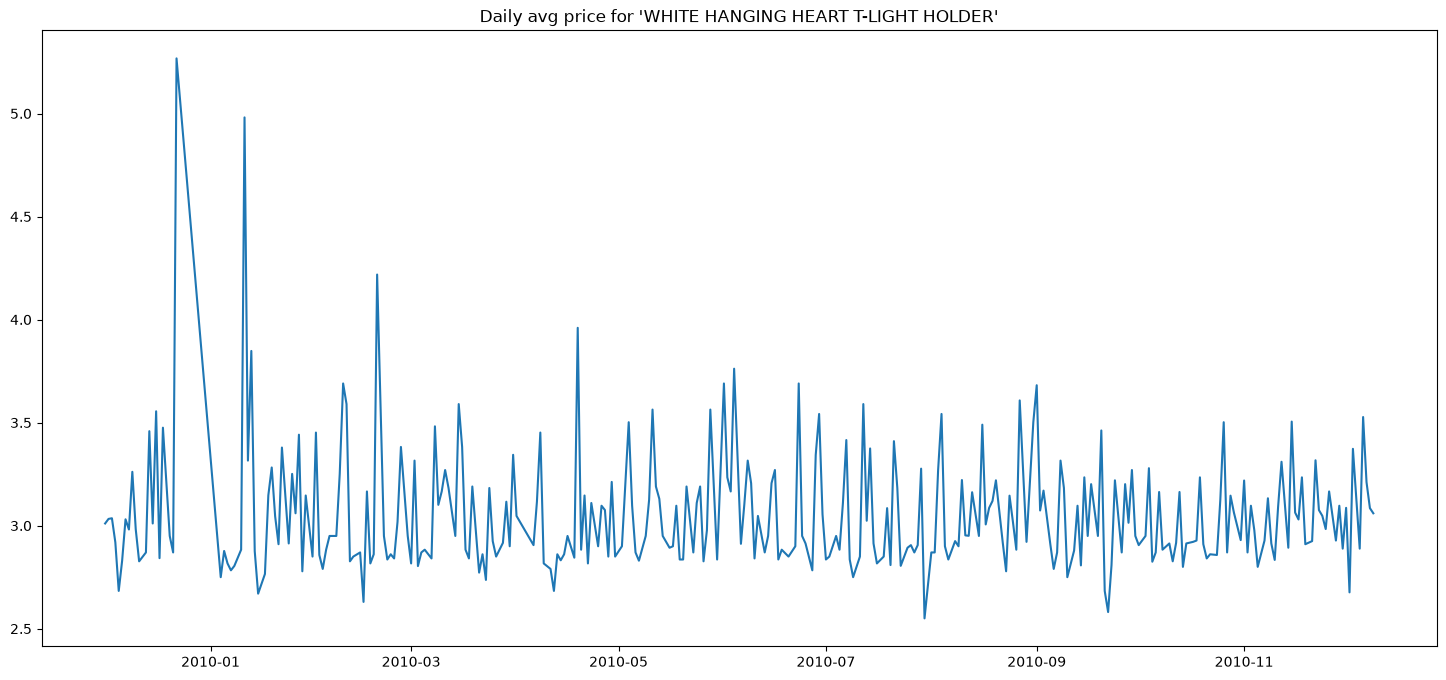

In [65]:
# See the actual distribution of price points
print(sales_only[sales_only['StockCode']=='85123A']['Price'].value_counts().sort_index())

# Daily average price instead of every raw invoice line
daily_price = (
    sales_only[sales_only['StockCode']=='85123A']
    .groupby(sales_only['InvoiceDate'].dt.date)['Price']
    .mean()
)
plt.figure(figsize=(18,8))
plt.plot(daily_price.index, daily_price.values)
plt.title("Daily avg price for 'WHITE HANGING HEART T-LIGHT HOLDER'")
plt.show()

Price
8.47        2
10.85       1
10.95     296
12.72      10
12.75    1433
25.49     299
25.95       1
29.95       2
Name: count, dtype: int64


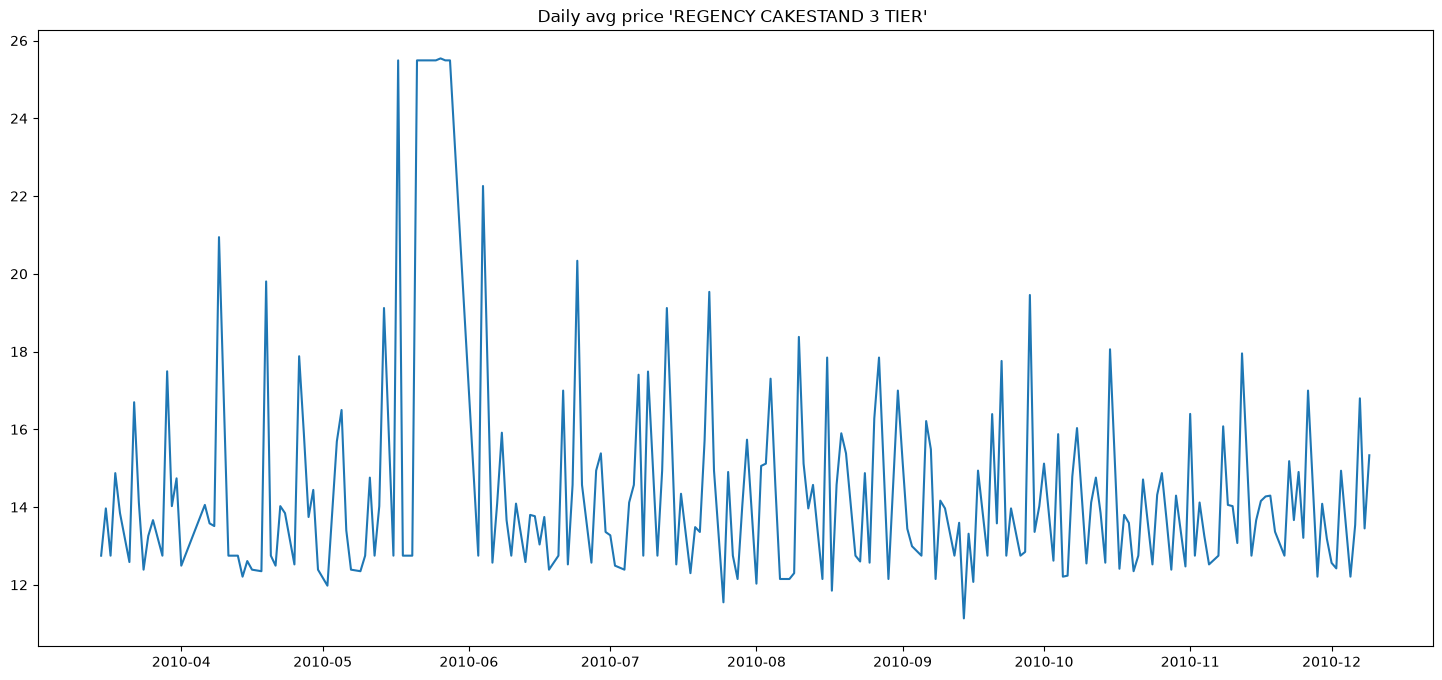

In [66]:
# See the actual distribution of price points
print(sales_only[sales_only['StockCode']=='22423']['Price'].value_counts().sort_index())

# Daily average price instead of every raw invoice line
daily_price = (
    sales_only[sales_only['StockCode']=='22423']
    .groupby(sales_only['InvoiceDate'].dt.date)['Price']
    .mean()
)

plt.figure(figsize=(18,8))
plt.plot(daily_price.index, daily_price.values)
plt.title("Daily avg price 'REGENCY CAKESTAND 3 TIER' ")
plt.show()